# Packages

In [2]:
import os
import glob
import re
from datetime import timedelta, datetime

import hist
import uproot

import dask
import awkward as ak
import dask_awkward as da
import dask.dataframe as dd
import dask_histogram as dh
from dask.diagnostics import ProgressBar

import boost_histogram as bh

from particle import Particle, ParticleNotFound

import numpy as np
from tqdm import tqdm
import matplotlib as mpl
import matplotlib.pyplot as plt

import pandas as pd


import time

import plotly.graph_objects as go


# Monitoring of kernel

In [ ]:
""" from dask.distributed import Client
import re
import socket

client = Client()

print(f"=== KERNEL NODE INFO ===")
print(f"Node/Hostname: {socket.gethostname()}")

# Client-Info anzeigen:
print(f"Scheduler address: {client.scheduler.address}")
print(f"Dashboard link: {client.dashboard_link}")

# Ports extrahieren:
scheduler_address = client.scheduler.address
dashboard_link = client.dashboard_link

# Port-Nummern aus den URLs extrahieren:
scheduler_port = re.findall(r':(\d+)', scheduler_address)[0]
dashboard_port = re.findall(r':(\d+)', dashboard_link)[0]

print(f"\n=== PORT FORWARDING INFO ===")
print(f"Scheduler Port: {scheduler_port}")
print(f"Dashboard Port: {dashboard_port}")

print(f"\n=== SSH COMMAND ===")
print(f"ssh -L {scheduler_port}:localhost:{scheduler_port} -L {dashboard_port}:localhost:{dashboard_port} -N bkoberg@palma")

print(f"\n=== DASHBOARD URL (nach Port-Forwarding) ===")
print(f"http://localhost:{dashboard_port}") """

=== KERNEL NODE INFO ===
Node/Hostname: r08n42
Scheduler address: tcp://127.0.0.1:37703
Dashboard link: http://127.0.0.1:8787/status

=== PORT FORWARDING INFO ===
Scheduler Port: 37703
Dashboard Port: 8787

=== SSH COMMAND ===
ssh -L 37703:localhost:37703 -L 8787:localhost:8787 -N bkoberg@palma

=== DASHBOARD URL (nach Port-Forwarding) ===
http://localhost:8787


In [ ]:
""" print(f"\n=== WORKER INFO ===")
for worker_id, worker_info in client.scheduler_info()['workers'].items():
    print(f"Worker: {worker_id}")
    print(f"  CPU Cores: {worker_info['nthreads']}")
    print(f"  Memory: {worker_info['memory_limit'] / 1024**3:.1f} GB")
    print(f"  Tasks: {worker_info.get('executing', 0)} executing, {worker_info.get('in_memory', 0)} in memory") """



=== WORKER INFO ===
Worker: tcp://127.0.0.1:32839
  CPU Cores: 4
  Memory: 12.8 GB
  Tasks: 0 executing, 0 in memory
Worker: tcp://127.0.0.1:35415
  CPU Cores: 4
  Memory: 12.8 GB
  Tasks: 0 executing, 0 in memory
Worker: tcp://127.0.0.1:38043
  CPU Cores: 4
  Memory: 12.8 GB
  Tasks: 0 executing, 0 in memory
Worker: tcp://127.0.0.1:43027
  CPU Cores: 4
  Memory: 12.8 GB
  Tasks: 0 executing, 0 in memory
Worker: tcp://127.0.0.1:46253
  CPU Cores: 4
  Memory: 12.8 GB
  Tasks: 0 executing, 0 in memory


****
# Observing and controlling

## While sim is running

In [3]:
log_dir = "/home/b/bkoberg/logs"
out_files = glob.glob(os.path.join(log_dir, "*.out"))

rows = []

for i, file in enumerate(out_files):
    with open(file, "r") as f:
        lines = f.readlines()

        perc = re.search(r"(\d+)%", lines[-1].strip())

        begin = re.search(r"(\d{4}-\d{1,2}-\d{1,2} \d{1,2}-\d{1,2}-\d{1,2})", lines[454].strip())
        now = re.search(r"(\d{4}-\d{1,2}-\d{1,2} \d{1,2}-\d{1,2}-\d{1,2})", lines[-1].strip())
        end = re.search(r"ETA: (\d{4}-\d{1,2}-\d{1,2} \d{1,2}-\d{1,2}-\d{1,2})", lines[-1].strip())

        fmt = "%Y-%m-%d %H-%M-%S"
        dt_start = datetime.strptime(begin.group(1), fmt) if begin else None
        dt_now = datetime.strptime(now.group(1), fmt) if now else None
        dt_ende = datetime.strptime(end.group(1), fmt) if end else None

        rows.append({
            "File": os.path.basename(file),
            "Progress": perc.group(1) if perc else None,
            "begin": dt_start,
            "end": dt_ende,
            "now": dt_now,
            "Time to go": (dt_ende - dt_now) if (dt_ende and dt_now) else None,
            "Total Time": (dt_ende - dt_start) if (dt_ende and dt_start) else None
        })

df = pd.DataFrame(rows)

row_min = df.loc[df["end"].idxmax()]
print(row_min)

File          simulation-33118589.out
Progress                           26
begin             2025-06-27 11:01:33
end               2025-06-28 06:27:47
now               2025-06-27 15:57:15
Time to go            0 days 14:30:32
Total Time            0 days 19:26:14
Name: 223, dtype: object


## After controle

In [4]:
log_dir = "/home/b/bkoberg/logs"
out_files = glob.glob(os.path.join(log_dir, "*.out"))

rows = []

for i, file in enumerate(out_files):
    with open(file, "r") as f:
        lines = f.readlines()

        

        exit_code_match = re.search(r"State:\s*(.*)", lines[-8].strip())
        if not exit_code_match:
            exit_code_match = re.search(r"State:\s*(.*)", lines[-9].strip())

        time_match = re.search(r"(\d{1,2}:\d{1,2}:\d{1,2})", lines[-4].strip())
        time = datetime.strptime(time_match.group(1), "%H:%M:%S") if time_match else None

        rows.append({
            "File": os.path.basename(file),
            "Exit Code": exit_code_match.group(1) if exit_code_match else None,
            "Lines": len(lines),
            "Time": time,
        })

df = pd.DataFrame(rows)

df_wak = df[df['Exit Code'] != 'COMPLETED (exit code 0)'] # either new datei or RUNNING

df_wak


,File,Exit Code,Lines,Time
0,simulation-33119587.out,None,598,None
1,simulation-33118966.out,None,564,None
2,simulation-33118716.out,None,564,None
3,simulation-33119026.out,None,567,None
4,simulation-33119628.out,None,575,None
...,...,...,...,...
495,simulation-33119729.out,None,563,None
496,simulation-33119577.out,None,563,None
497,simulation-33118476.out,None,581,None
498,simulation-33118353.out,None,577,None


***
# Loading using dask

In [75]:
data_path = "/home/b/bkoberg/AGW_LowRad/data_sim/XeSim_Neutron"
path_Version = "4_7e82d44"
path_Material = "NoAbsorber"
path_length = "10cm"

min_data_file_size = 5 * 1024 * 1024
data_files = glob.glob(f"{data_path}/{path_Version}/{path_Material}/{path_length}/*.root")
print(f"Found {len(data_files)} files matching pattern '{path_length}' in '{data_path}/{path_Version}/{path_Material}/{path_length}/'.")

uproot_files = [{f:"events/events"} for f in data_files if os.path.getsize(f) > min_data_file_size]
print(f"Available keys in uproot files: {uproot.open(uproot_files[0]).keys()}")

Found 500 files matching pattern '10cm' in '/home/b/bkoberg/AGW_LowRad/data_sim/XeSim_Neutron/4_7e82d44/NoAbsorber/10cm/'.
Available keys in uproot files: ['eventid', 'type_pri', 'type_pri_id', 'e_pri', 'xp_pri', 'yp_pri', 'zp_pri', 'cx_pri', 'cy_pri', 'cz_pri', 'vol_pri', 'vol_pri_hash', 'NSave', 'Save_flag', 'Save_desc', 'Save_type', 'Save_x', 'Save_y', 'Save_z', 'Save_cx', 'Save_cy', 'Save_cz', 'Save_e', 'Save_t', 'Save_eventid', 'Save_trackid', 'Save_volume', 'NNAct', 'NAct_eventid', 'NAct_trackid', 'NAct_parentid', 'NAct_t', 'NAct_volume', 'NAct_volume_hash', 'NAct_x', 'NAct_y', 'NAct_z', 'NAct_process_name', 'NAct_process_category', 'NAct_process_ID', 'NAct_particle_name', 'NAct_particle_lifetime', 'NAct_particle_id', 'NAct_particle_atomicnumber', 'NAct_particle_mass', 'NAct_particle_excitationEnergy']


In [76]:
num = 1
uproot_files = uproot_files[:num]

In [77]:
arr = uproot.dask(uproot_files, filter_name=uproot.open(uproot_files[0]).keys(), allow_missing=True, step_size="180MB")
arr['type_pri_id'] = ak.flatten(arr['type_pri_id'])

arr = arr[arr['type_pri_id'] == 2112]

In [78]:
pictures_path = '/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures'
if not os.path.exists(f'{pictures_path}/{path_Version}/{path_Material}/{path_length}'):
    os.makedirs(f'{pictures_path}/{path_Version}/{path_Material}/{path_length}')

In [79]:
data_path = '/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data'
if not os.path.exists(f'{data_path}/{path_Version}/{path_Material}/{path_length}'):
    os.makedirs(f'{data_path}/{path_Version}/{path_Material}/{path_length}')

np.savez("/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/config.npz",
         path_Version=path_Version,
         path_Material=path_Material,
         path_length=path_length,
         num=num)

## Meta-Daten und Tabellen für IDs

In [80]:
file = f"/home/b/bkoberg/AGW_LowRad/data_sim/XeSim_Neutron/{path_Version}/{path_Material}/{path_length}/0.root"
rfile = uproot.open(file)

print(f"The file contains {len(rfile.keys())} keys:")
for key in rfile.keys():
    print(f"  {key}")

print(f"\nExecuted with G4VERSION {rfile['G4VERSION_TAG'].member('fTitle')}")
print(f"Total runtime: {rfile['G4RUNTIME'].member('fVal')} seconds")
print(f"Number of events: {rfile['events/nbevents'].member('fVal')}")

print(f"\nUsing the macros:")
for macro in rfile["macros"].keys():
    print(f"--> {rfile['macros'][macro].member('fName')}")
    print(f"    File content hidden for brevity ...")
    for line in rfile["macros"][macro].member('fTitle').splitlines():
        print(f"    {line}")
    print("")

The file contains 32 keys:
  G4VERSION_TAG;1
  MC_TAG;1
  MCVERSION_TAG;1
  macros;1
  macros/preinit.mac;1
  macros/det_setup.mac;1
  macros/src_neutron.mac;1
  tables;1
  tables/neutronXS_G4_AIR;1
  tables/neutronXS_G4_WATER;1
  tables/neutronXS_G4_Galactic;1
  tables/neutronXS_LXe;1
  tables/neutronXS_LXe_nA;1
  tables/neutronXS_Rock;1
  tables/neutronXS_Concrete;1
  tables/neutronXS_SS304LSteel;1
  tables/neutronXS_Paraffin;1
  tables/neutronXS_Paraffin25;1
  tables/neutronXS_Polyethylen;1
  tables/neutronXS_Polyethylen5;1
  tables/neutronXS_Polyethylen25;1
  tables/neutronXS_Polyethylen25_G4Boron;1
  tables/neutronXS_Polyethylen7Lit;1
  tables/neutronXS_Silicone5;1
  tables/neutronXS_Silicone25Lit6;1
  tables/process_subtypes;1
  tables/logical_volumes;1
  tables/physical_volumes;1
  events;1
  events/nbevents;1
  events/events;1
  G4RUNTIME;1

Executed with G4VERSION $Name: geant4-10-06-patch-02 $
Total runtime: 58175.300851059 seconds
Number of events: 4000000

Using the macros:

In [81]:
rfile = uproot.open(file)

physical_volumes = {}
for k,v in zip(*rfile["tables/physical_volumes"].arrays(library="np", how=list)):
    physical_volumes = {**physical_volumes, **{k: v for k, v in zip(k, v)}}

def get_volume_name(volume_id):
    """Get the volume name from the volume ID."""
    _hashes = {v:k for k,v in physical_volumes.items()}
    if volume_id in _hashes:
        return _hashes[volume_id]
    else:
        return f"Unknown volume ID {volume_id}"

subtypes_table = rfile["tables/process_subtypes"].arrays(library="np")

particle_ids = {}
for k,v in zip(subtypes_table['particle_id'], subtypes_table['particle_name']):
    particle_ids = {**particle_ids, **{k: v for k, v in zip(k, v)}}

def get_particle_name(particle_id):
    """Get the particle name from the particle PDG code."""
    if particle_id in particle_ids:
        return particle_ids[particle_id]
    else:
        try:
            try:
                particle = Particle.from_pdgid(particle_id)
                return particle.name
            except ParticleNotFound:
                # Check if nucleus
                if (str(particle_id)[0:2] == "10"):
                    # Remove isomeric state
                    _particle_id = int(str(particle_id)[:9] + "0")
                    particle = Particle.from_pdgid(_particle_id)
                    return particle.name+f"({str(particle_id)[9:]})"
                raise
        except Exception as e:
            return f"Unknown particle code {particle_id}"

process_subtype = {}
for k,v in zip(subtypes_table['process_subtype'], subtypes_table['process_name']):
    process_subtype = {**process_subtype, **{k: v for k, v in zip(k, v)}}

def get_process_name(process_id):
    """Get the process name from the process ID."""
    if process_id in process_subtype:
        return process_subtype[process_id]
    else:
        return f"Unknown process ID {process_id}"

In [82]:
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
        "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22"]
edge_colors = ["#0d3b66", "#b4440e", "#1e6823", "#7c0e1e", "#5e3a8a",
        "#5d4037", "#b21d7c", "#4d4d4d", "#878d32"]

In [83]:
processes = ['conv', 'nCapture', 'RadioactiveDecayBase', 'xi0Inelastic', 'hadElastic']
volumes = ['Absorber', 'LXe','LXeContainer', ]
colors_process = {p: colors[i] for i, p in enumerate(processes)}
colors_Volumes = {v: edge_colors[i] for i, v in enumerate(volumes)}
colors_edges = {v: edge_colors[i] for i, v in enumerate(volumes)}

## NC Energydependent


In [71]:
df_pri = da.to_dataframe(arr[['e_pri']])
df = da.to_dataframe(arr[['e_pri', 'NAct_process_ID', 'NAct_volume_hash']])

### In Liquid Xenon

In [72]:
only_LXe_volume = df[df['NAct_volume_hash'] == physical_volumes['LXe']]
only_nCapture = only_LXe_volume[only_LXe_volume['NAct_process_ID'] == 131]  #nCapture
data = only_nCapture[['e_pri']]

In [73]:
bins = 101
ranges = (0,10000)

hist_pri = dh.histogram(df_pri['e_pri'], bins=bins, range=ranges)
hist = dh.histogram(data['e_pri'], bins=bins, range=ranges)

In [74]:
with ProgressBar():
    hist_pri_vals = hist_pri[0].compute()
    hist_pri_edges = hist_pri[1].compute()
    hist_vals = hist[0].compute()
    hist_edges = hist[1].compute()

[########                                ] | 20% Completed | 128.08 s


KeyboardInterrupt: 

In [ ]:
path = "/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/4_7e82d44/NoAbsorber/10cm/EnergyNC_LXe.npz"
np.savez(path, 
         hist_pri_vals=hist_pri_vals, 
         hist_pri_edges=hist_pri_edges, 
         hist_vals=hist_vals, 
         hist_edges=hist_edges)

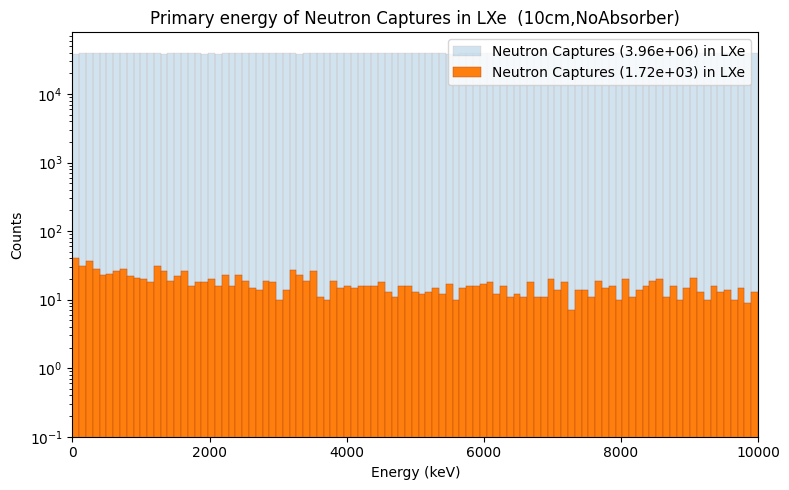

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(
    hist_pri_edges[:-1], hist_pri_vals,
    width=np.diff(hist_edges),
    align='edge',
    color=colors[0], alpha=0.2,
    edgecolor=edge_colors[1], linewidth=0.3,
    label=f'Neutron Captures ({hist_pri_vals.sum():.2e}) in LXe'
)

plt.bar(
    hist_edges[:-1], hist_vals,
    width=np.diff(hist_edges),
    align='edge',
    color=colors[1], alpha=1,
    edgecolor=edge_colors[1], linewidth=0.3,
    label=f'Neutron Captures ({hist_vals.sum():.2e}) in LXe'
)
plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.yscale('log')
plt.ylim(0.1, hist_pri_vals.max() * 2)
plt.xlim(0, 10000)
plt.title(f'Primary energy of Neutron Captures in LXe  ({path_length},{path_Material})')
plt.tight_layout()
plt.legend()
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/EnergyNC_LXe.pdf")
plt.show()

### In Absorber

In [18]:
only_Absorber_volume = df[df['NAct_volume_hash'] == physical_volumes['Absorber']]
only_nCapture = only_Absorber_volume[only_Absorber_volume['NAct_process_ID'] == 131]  #nCapture
data = only_nCapture[['e_pri']]

In [19]:
bins = 101
ranges = (0,10000)

hist_pri = dh.histogram(df_pri['e_pri'], bins=bins, range=ranges)
hist = dh.histogram(data['e_pri'], bins=bins, range=ranges)

In [20]:
with ProgressBar():
    hist_pri_vals = hist_pri[0].compute()
    hist_pri_edges = hist_pri[1].compute()
    hist_vals = hist[0].compute()
    hist_edges = hist[1].compute()

[########################################] | 100% Completed | 315.37 ms
[########################################] | 100% Completed | 100.96 ms
[########################################] | 100% Completed | 2.47 ss
[########################################] | 100% Completed | 100.94 ms


In [21]:
path = "/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/4_7e82d44/NoAbsorber/10cm/EnergyNC_Absorber.npz"
np.savez(path, 
         hist_pri_vals=hist_pri_vals, 
         hist_pri_edges=hist_pri_edges, 
         hist_vals=hist_vals, 
         hist_edges=hist_edges)

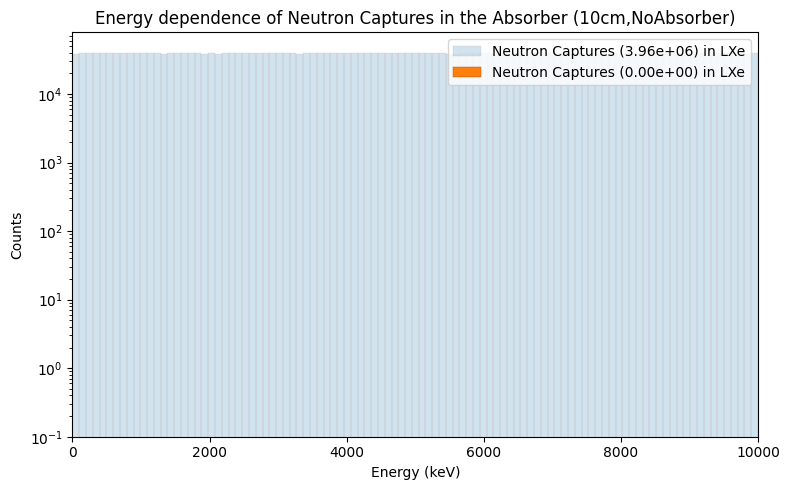

In [22]:
plt.figure(figsize=(8, 5))
plt.bar(
    hist_pri_edges[:-1], hist_pri_vals,
    width=np.diff(hist_edges),
    align='edge',
    color=colors[0], alpha=0.2,
    edgecolor=edge_colors[1], linewidth=0.3,
    label=f'Neutron Captures ({hist_pri_vals.sum():.2e}) in LXe'
)

plt.bar(
    hist_edges[:-1], hist_vals,
    width=np.diff(hist_edges),
    align='edge',
    color=colors[1], alpha=1,
    edgecolor=edge_colors[1], linewidth=0.3,
    label=f'Neutron Captures ({hist_vals.sum():.2e}) in LXe'
)
plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.yscale('log')
plt.ylim(0.1, hist_pri_vals.max() * 2)
plt.xlim(0, 10000)
plt.title(f'Energy dependence of Neutron Captures in the Absorber ({path_length},{path_Material})')
plt.tight_layout()
plt.legend()
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/EnergyNC_Absorber.pdf" )
plt.show()

## Processes

In [84]:
df = da.to_dataframe(arr[['e_pri', 'NAct_particle_id', 'NAct_process_ID', 'NAct_volume_hash']])

### Xenon Volume

In [85]:
only_LXe_volume = df[df['NAct_volume_hash'] == physical_volumes['LXe']]

only_nCapture = only_LXe_volume[only_LXe_volume['NAct_process_ID'] == 131]  #nCapture

data = only_nCapture[['NAct_particle_id','NAct_process_ID']]

In [86]:
with ProgressBar():
    grouped_data = data.groupby(['NAct_particle_id','NAct_process_ID']).size().compute()


grouped_data.index = grouped_data.index.set_levels(
    grouped_data.index.levels[0].map(lambda x: get_particle_name(x)), level = 0
)
grouped_data.index = grouped_data.index.set_levels(
    grouped_data.index.levels[1].map(lambda x: get_process_name(x)), level = 1
)


[########################################] | 100% Completed | 3.89 ss


In [89]:
path = "/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/4_7e82d44/NoAbsorber/10cm/Processes_LXe.npz"
np.savez(path, 
         grouped_data_values=grouped_data.values,
         grouped_data_index_level0=grouped_data.index.get_level_values(0).values,
         grouped_data_index_level1=grouped_data.index.get_level_values(1).values)


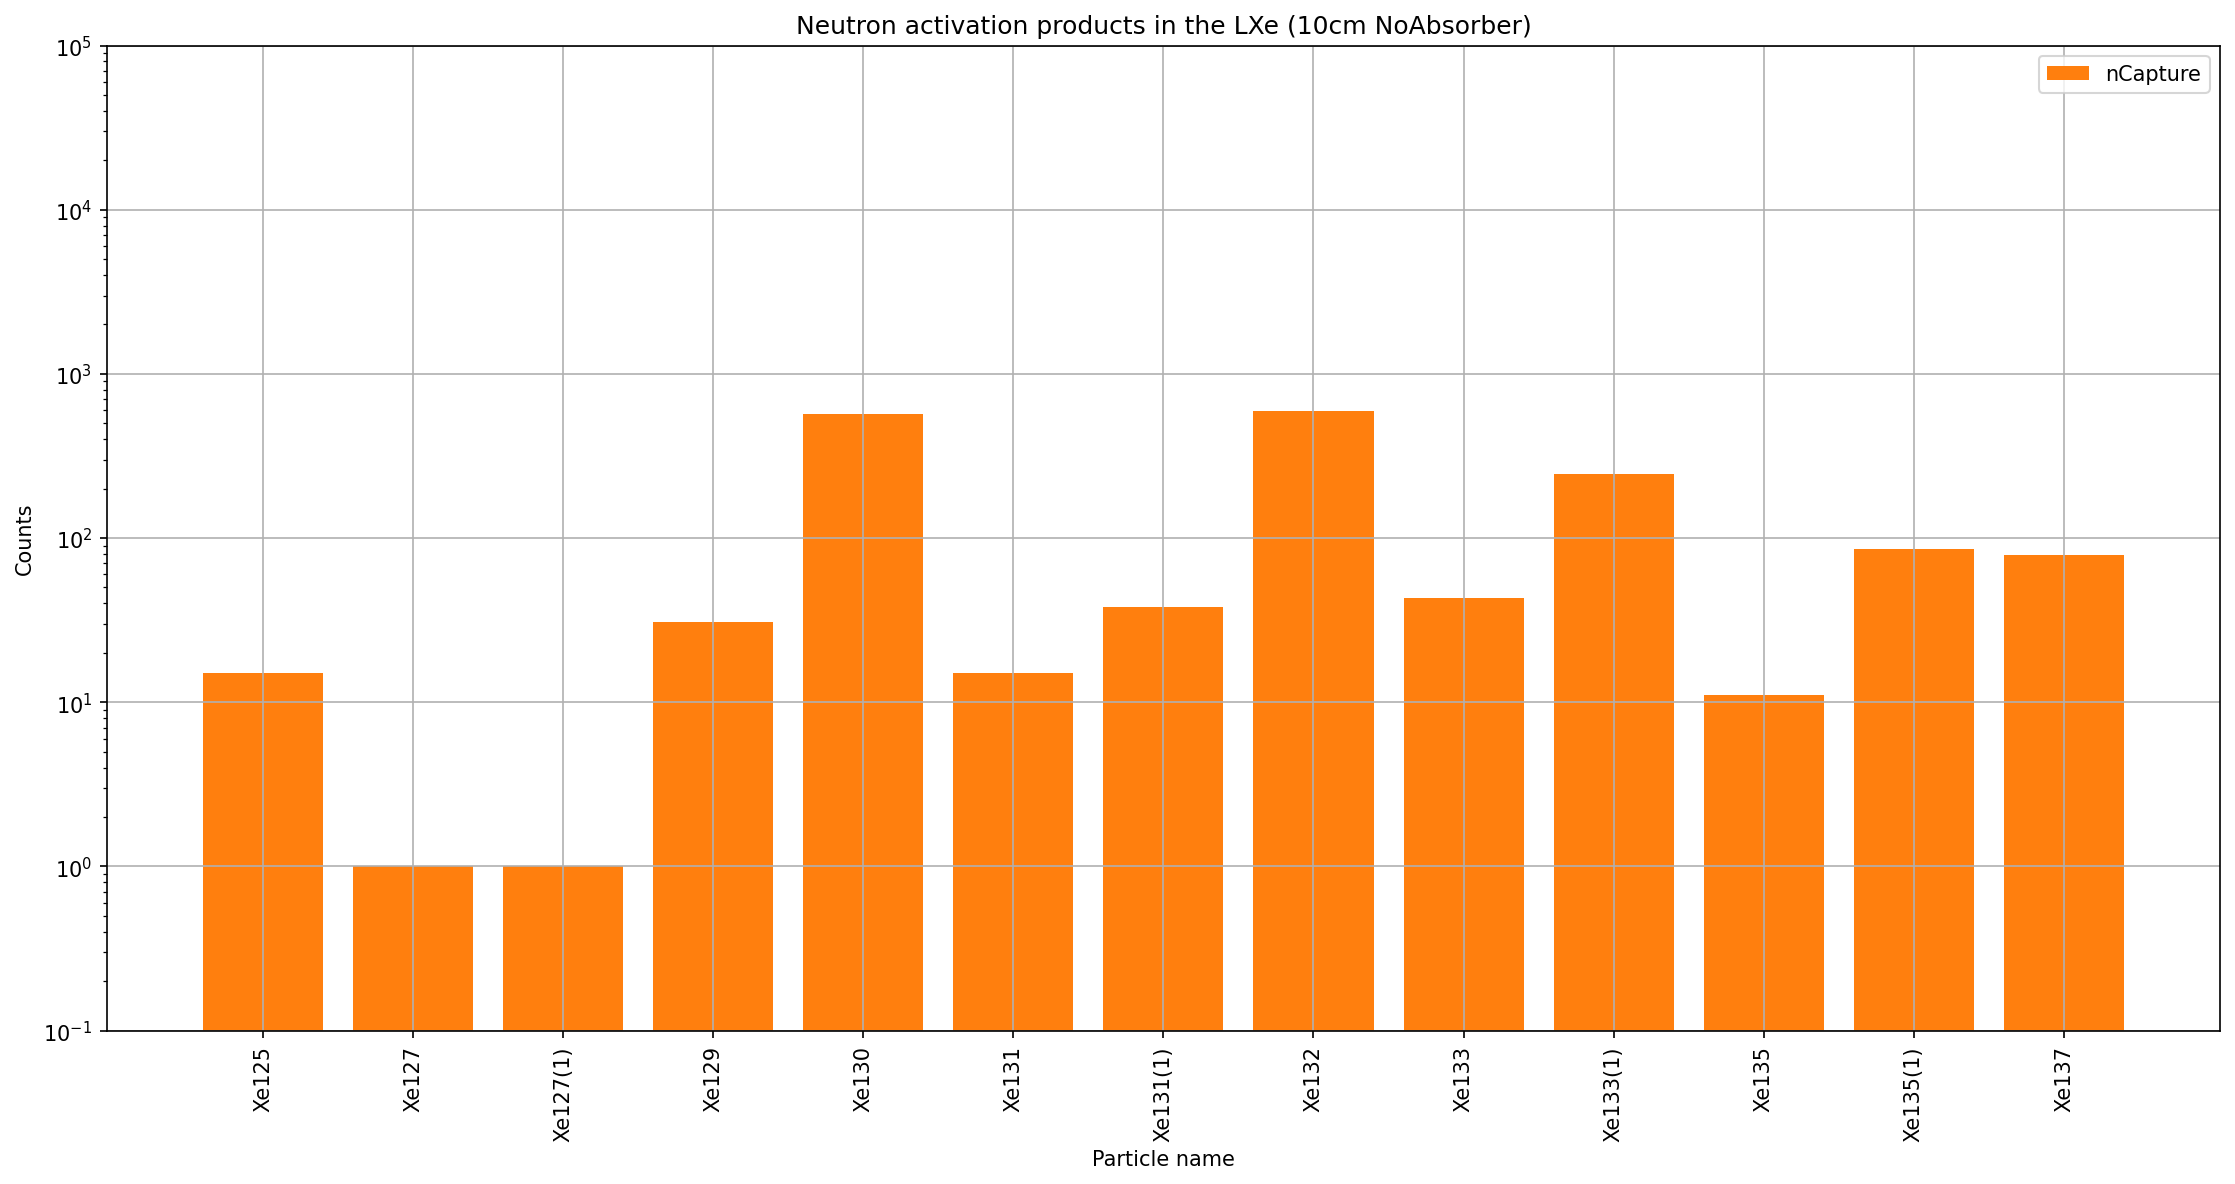

In [88]:
_data = grouped_data#[grouped_data.values > 40]

_particles = np.unique(_data.index.get_level_values(0))
_processes = np.unique(_data.index.get_level_values(1))

def get_value(data,pr,p):
    try:
        return data[p,pr]
    except:
        return 0
    
_counts = {pr: [get_value(_data,pr,p) for p in _particles] for pr in _processes} 
_processes_sorted = sorted(_processes, key=lambda pr: sum(_counts[pr]))
color = {pr: colors[idx % len(colors)] for idx, pr in enumerate(_processes_sorted)}


plt.figure(dpi=150, figsize =(15,8))

x = np.arange(len(_particles))
bottom = np.zeros(len(_particles))
for idx, pr in enumerate(_processes_sorted):
    plt.bar(x, _counts[pr], 0.8, label=pr, bottom=bottom, color=colors_process[pr])
    bottom += np.array(_counts[pr])

ax = plt.gca()
ax.set_xticks(x)
ax.set_xticklabels(_particles, rotation=90, ha='center')

plt.xlabel("Particle name")
plt.ylabel("Counts")
plt.title("Neutron activation products in the LXe ({} {})".format(path_length, path_Material))
plt.yscale("log")
plt.ylim(0.1,1e5)

plt.legend()
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/Processes_LXe.pdf" )
plt.tight_layout()
plt.grid()

plt.show()




### Absorber Volume

In [28]:
only_Absorber_volume = df[df['NAct_volume_hash'] == physical_volumes['Absorber']]

data = only_Absorber_volume[['NAct_particle_id','NAct_process_ID']]

In [29]:
with ProgressBar():
    grouped_data = data.groupby(['NAct_particle_id','NAct_process_ID']).size().compute()


grouped_data.index = grouped_data.index.set_levels(
    grouped_data.index.levels[0].map(lambda x: get_particle_name(x)), level = 0
)
grouped_data.index = grouped_data.index.set_levels(
    grouped_data.index.levels[1].map(lambda x: get_process_name(x)), level = 1
)


[########################################] | 100% Completed | 2.87 ss


In [30]:
path = "/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/4_7e82d44/NoAbsorber/10cm/Processes_Absorber.npz"
np.savez(path, 
         grouped_data=grouped_data)

0
1
2
3


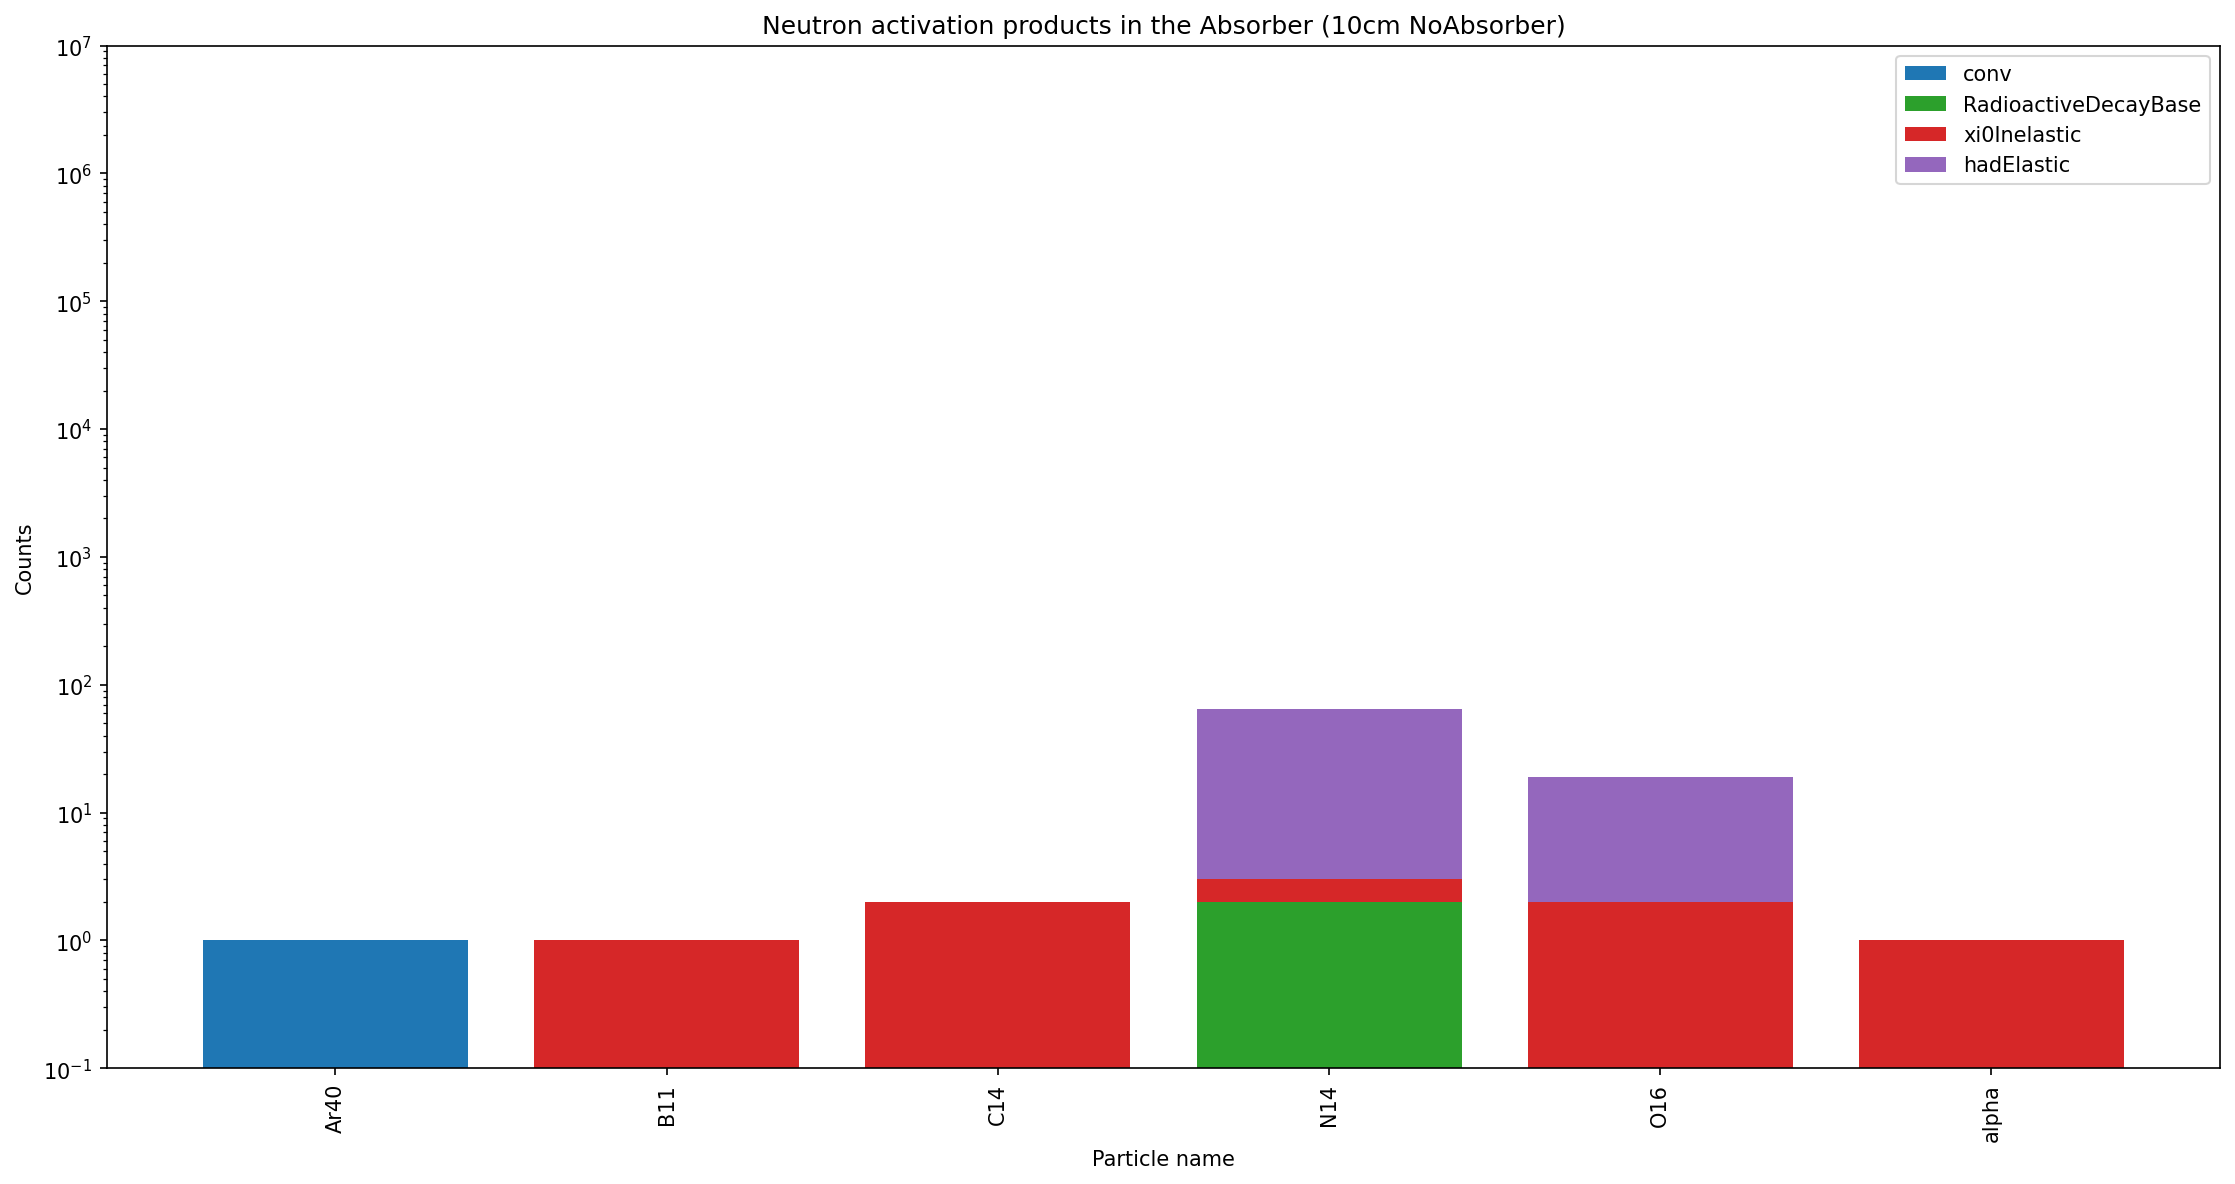

In [31]:
_data = grouped_data#[grouped_data.values > 40]
#_data = grouped_data

_particles = np.unique(_data.index.get_level_values(0))
_processes = np.unique(_data.index.get_level_values(1))



def get_value(data,pr,p):
    try:
        return data[p,pr]
    except:
        return 0

_counts = {pr: [get_value(_data,pr,p) for p in _particles] for pr in _processes} 
_processes_sorted = sorted(_processes, key=lambda pr: sum(_counts[pr]))

plt.figure(dpi=150, figsize =(15,8))

x = np.arange(len(_particles))
bottom = np.zeros(len(_particles))
for idx, pr in enumerate(_processes_sorted):
    print(idx)
    plt.bar(x, _counts[pr], 0.8, label=pr, bottom=bottom, color=colors_process[pr])
    bottom += np.array(_counts[pr])

ax = plt.gca()
ax.set_xticks(x)
ax.set_xticklabels(_particles, rotation=90, ha='center')

plt.xlabel("Particle name")
plt.ylabel("Counts")
plt.title("Neutron activation products in the Absorber ({} {})".format(path_length, path_Material))
plt.yscale("log")
plt.ylim(0.1,1e7)

plt.legend()
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/Processes_Absorber.pdf" )
plt.tight_layout()
plt.show()



In [ ]:
plt.figure(dpi=150, figsize=(15, 8))

x = np.arange(len(_particles))
bar_width = 0.8 / len(_processes)  # Balken schmaler machen, damit sie nebeneinander passen

for i, pr in enumerate(_processes):
    plt.bar(x + i * bar_width, _counts[pr], bar_width, label=pr)

ax = plt.gca()
ax.set_xticks(x + bar_width * (len(_processes)-1)/2)
ax.set_xticklabels(_particles, rotation=90, ha='center')

plt.xlabel("Particle name")
plt.ylabel("Counts")
plt.title("Neutron activation products in the Absorber")
plt.yscale("log")
plt.ylim(0.1, 1e7)
plt.legend()
plt.tight_layout()
plt.show()

## Energy Distributions trend

In [37]:
df_pri = da.to_dataframe(arr[['e_pri','type_pri_id']])

df = da.to_dataframe(arr[['eventid','Save_desc', 'Save_e', 'Save_volume', 'Save_trackid']])

df_NAct = da.to_dataframe(arr[['eventid','NAct_process_name', 'NAct_trackid', 'NAct_volume']])

In [38]:
labels = ['e_pri','Absorber', 'LXe', 'LXeContainer']

#df = df[df['Save_trackid'] < 5]

arrays = [df_pri[['e_pri']]]
arrays += [df[(df['Save_desc'] == "Absorber") & (df['Save_volume'] == 'BuildAir')]['Save_e']]
#arrays += [df[df['Save_desc'] == "AbsorberAir"]['Save_e']]
arrays += [df[df['Save_desc'] == "LXe"]['Save_e']]
arrays += [df[(df['Save_desc'] == "LXeContainer")]['Save_e']]


In [39]:
hist_tasks = []
bins = []

for i in range(len(arrays)):
    hist_task, bin_edges = dh.histogram(arrays[i], bins=100, range=(0,15000))
    hist_tasks.append(hist_task)
    bins.append(bin_edges)


In [40]:
with ProgressBar():
    hist_vals_list = [a.compute() for a in hist_tasks]
    bin_edges_list = [b.compute() for b in bins]


[########################################] | 100% Completed | 315.03 ms
[########################################] | 100% Completed | 1.14 sms
[########################################] | 100% Completed | 1.15 sms
[########################################] | 100% Completed | 1.05 sms
[########################################] | 100% Completed | 101.08 ms
[########################################] | 100% Completed | 100.88 ms
[########################################] | 100% Completed | 101.01 ms
[########################################] | 100% Completed | 100.98 ms


In [41]:
path = "/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/4_7e82d44/NoAbsorber/10cm/EnergyDistributions_Volumes.npz"
np.savez(path, 
         hist_vals_list=hist_vals_list, 
         bin_edges_list=bin_edges_list,
         labels=labels)

0
1
3
2


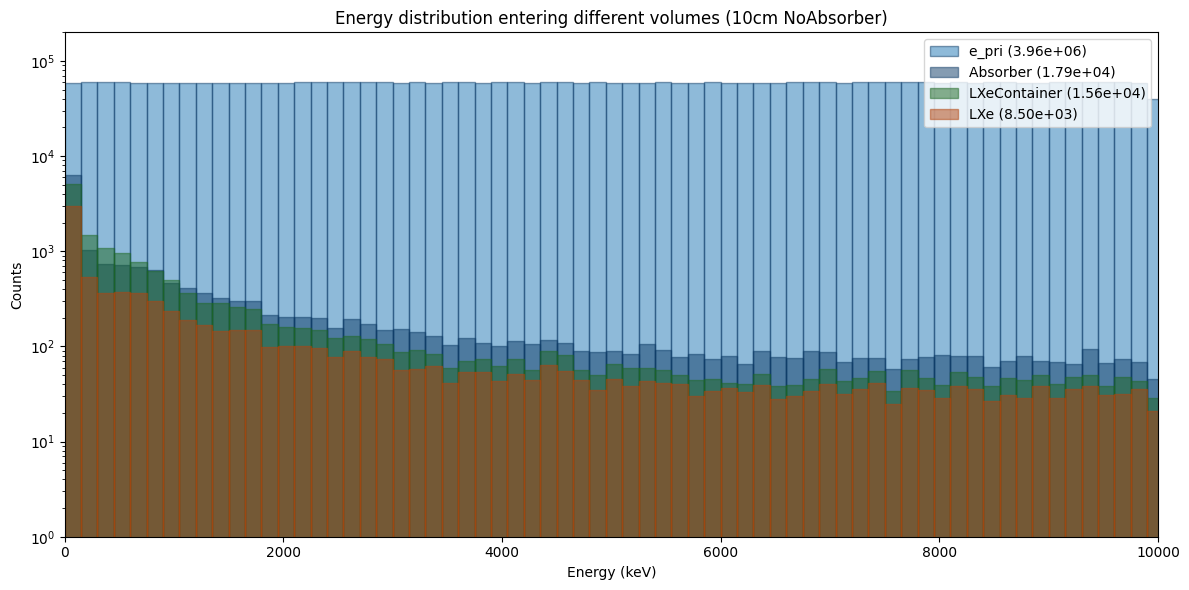

In [42]:
plt.figure(figsize=(12, 6))

all_indices = [
    i for i in range(len(hist_vals_list))
]

# Nach Länge sortieren (absteigend)
# Sortiere die Indizes nach der Summe der Histogrammwerte
all_indices_sorted = sorted(
    all_indices,
    key=lambda i: sum(hist_vals_list[i]),
    reverse=True
)



for i in all_indices_sorted:
    print(i)
    # Use colors_Volumes and volumes only for indices 1,2,3 (since volumes has length 3)
    if i > 0 and (i-1) < len(volumes):
        bar_color = colors_Volumes[volumes[i-1]]
        bar_edge_color = colors_edges[volumes[i-1]]
    else:
        bar_color = colors[0]
        bar_edge_color = edge_colors[0] if isinstance(edge_colors, list) else colors[0]
    # Use bar_edge_color safely
    plt.bar(bin_edges_list[i][:-1], hist_vals_list[i],
            width=bin_edges_list[i][1] - bin_edges_list[i][0],
            align='edge',
            color=bar_color, edgecolor=bar_edge_color,
            label=f'{labels[i]} ({sum(hist_vals_list[i]):.2e})',
            alpha=0.5)

plt.xlim(0, 10000)

plt.yscale('log')
plt.ylim(1,2e5)

plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.title('Energy distribution entering different volumes ({} {})'.format(path_length, path_Material))
plt.tight_layout()
plt.legend()
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/EnergyDistributions_Volumes.pdf" )
plt.show()

## Positions

### 2D

In [47]:
df_pri = da.to_dataframe(arr[['xp_pri', 'yp_pri', 'zp_pri']])
df_NAct = da.to_dataframe(arr[[ 'NAct_x', 'NAct_y', 'NAct_z', 'NAct_volume']])
df_Save = da.to_dataframe(arr[['Save_x', 'Save_y', 'Save_z', 'Save_volume', 'Save_desc']])


In [48]:
df_Save = df_Save[df_Save['Save_desc'] == "Absorber"]

In [49]:
border = 0.1
ranges = []
dfs = [df_pri, df_NAct, df_Save]
coords = [['xp_pri', 'yp_pri', 'zp_pri'], ['NAct_x', 'NAct_y', 'NAct_z'], ['Save_x', 'Save_y', 'Save_z']]

ranges = [[
    (-12000, 12000),  # xp_pri
    (-16000, 16000),  # yp_pri
    (-1000, 21000)],     # zp_pri
    [(-16000, 16000),  # NAct_x
    (-16000, 16000),  # NAct_y
    (-3000, 27000)],      # NAct_z
    [(-500, 500),  # Save_x
    (-2000, 2000),  # Save_y
    (1000, 5000)]      # Save_z
]


""" maximum = [ranges[j][1][1]-ranges[j][1][0] for j in range(len(ranges))]
maximum_bins = 300
bins_all = [[(ranges[j][i][1]-ranges[j][i][0]) / maximum[j] * maximum_bins 
             for i in range(len(ranges[j]))] 
             for j in range(len(ranges))]

bins_all[2] = [100, 100, 100] """

#bins_all = [[50, 50, 50], [50, 50, 50], [50, 50, 50]]
bins_all = [[100, 100, 100], [100, 100, 100], [200, 100, 100]]

In [50]:

h3d_computed = []
for i, coord in enumerate(coords):
    bins = [int(b) for b in bins_all[i]]
    h3d = dh.histogramdd([dfs[i][coord[0]], dfs[i][coord[1]], dfs[i][coord[2]]], bins=bins, range=ranges[i], histogram=True)
    with ProgressBar():
        h3d_computed.append(h3d.compute())

[                                        ] | 0% Completed | 241.15 us

[########################################] | 100% Completed | 538.28 ms
[########################################] | 100% Completed | 16.32 s
[########################################] | 100% Completed | 1.60 ss


In [57]:
path = "/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/4_7e82d44/NoAbsorber/10cm/Positions.npz"
np.savez(path, 
         h3d_computed=np.array(h3d_computed, dtype=object),
         coords=np.array(coords, dtype=object),
         ranges=np.array(ranges, dtype=object),
         bins_all=np.array(bins_all, dtype=object),
         allow_pickle=True)

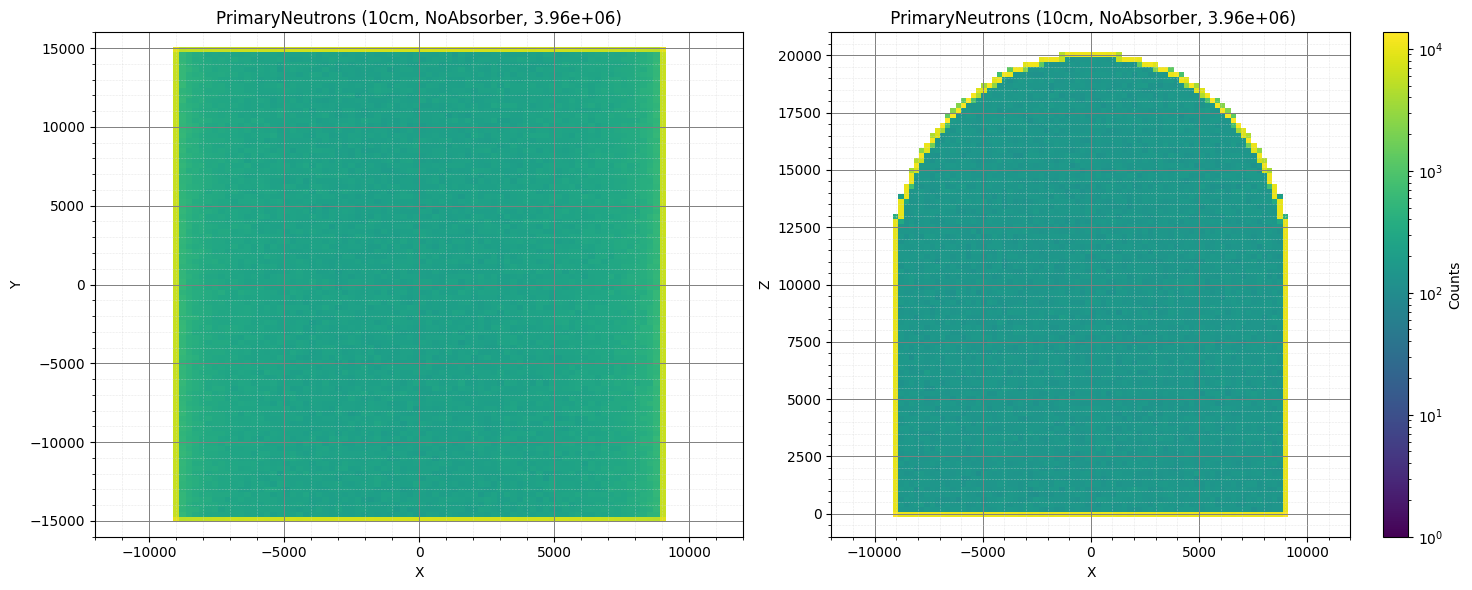

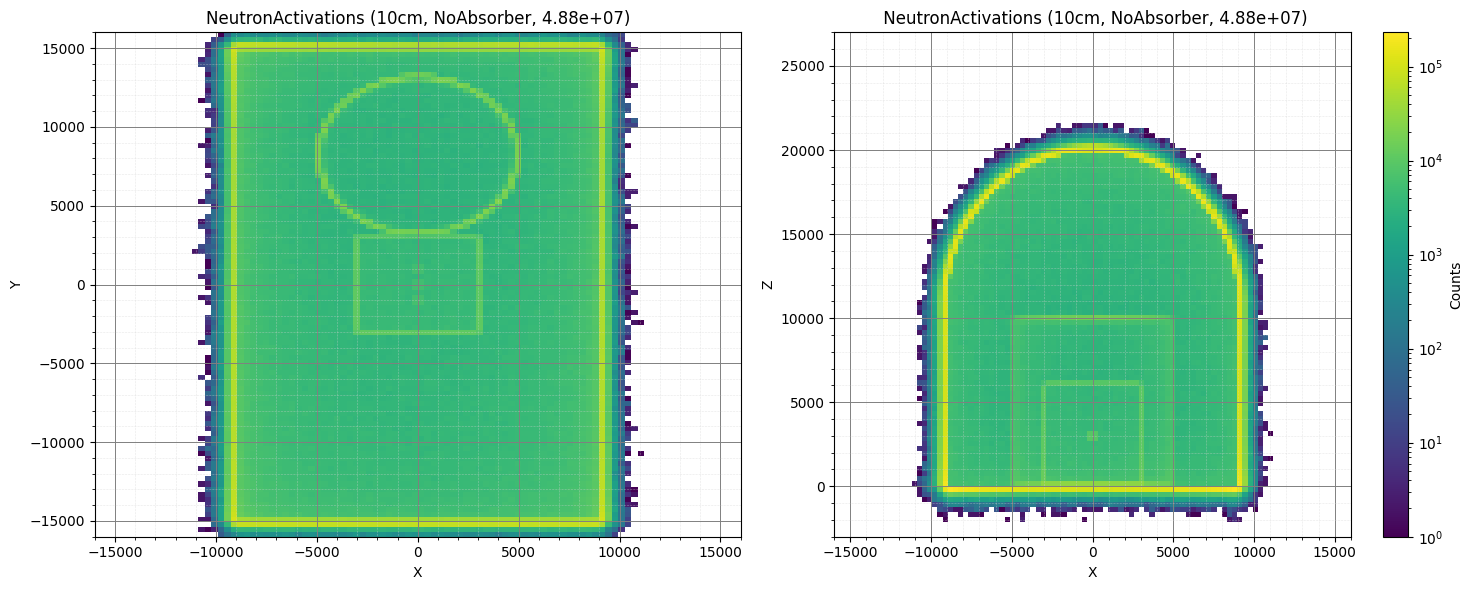

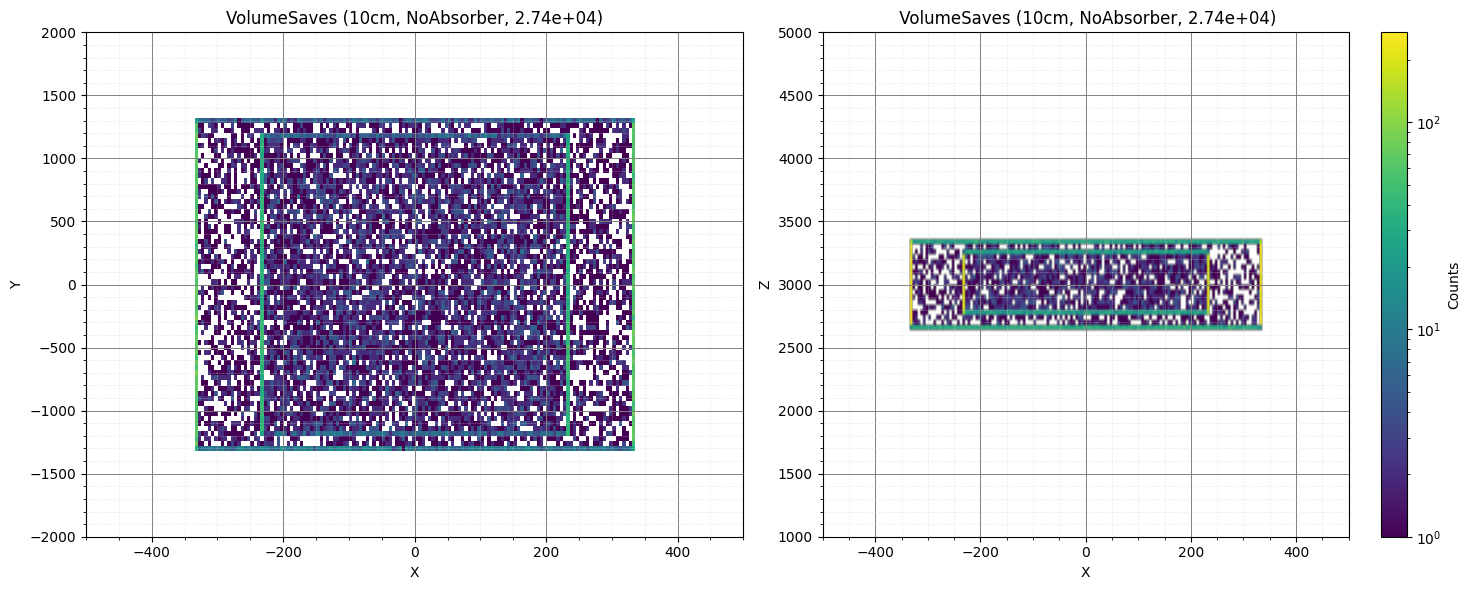

In [58]:
grid = True

for i,coord in enumerate(coords):
    if i == 0:
        a='PrimaryNeutrons'
    elif i == 1:
        a='NeutronActivations'
    elif i == 2:
        a='VolumeSaves'

    x_range, y_range, z_range = ranges[i]
    x_bins, y_bins, z_bins = bins_all[i]

    xy_proj = h3d_computed[i][:,:,sum].view()
    xz_proj = h3d_computed[i][:,sum,:].view()
    max_val = max(xy_proj.max(), xz_proj.max())
    all = h3d_computed[i].sum()

    fig ,ax = plt.subplots(nrows = 1, ncols = 2, figsize=(15, 6))

    aspect = 'auto'

    norm = mpl.colors.LogNorm(vmin=1, vmax=max_val) 
    #norm = mpl.colors.Normalize(vmin=1, vmax=max_val*0.1)  # Use Normalize for linear scaling
    #aspect = 'equal'

    ax[0].imshow(
        xy_proj.T,  
        extent=(x_range[0], x_range[1], y_range[0], y_range[1]),
        origin='lower',
        aspect=aspect,
        norm=norm
    )
    ax[0].set_xlabel('X')
    ax[0].set_ylabel('Y')
    ax[0].set_title(f'{a} ({path_length}, {path_Material}, {all:.2e})')



    # XZ-Projektion (Summe über y)
    ax[1].imshow(
        xz_proj.view().T,
        extent=(x_range[0], x_range[1], z_range[0], z_range[1]),
        origin='lower',
        aspect=aspect,
        norm=norm
    )
    ax[1].set_xlabel('X')
    ax[1].set_ylabel('Z')
    ax[1].set_title(f' {a} ({path_length}, {path_Material}, {all:.2e})')

    if grid:
        ax[0].minorticks_on()
        ax[0].grid(which='major', linestyle='-', linewidth=0.7, color='gray')
        ax[0].grid(which='minor', linestyle=':', linewidth=0.4, color='lightgray')
        ax[1].minorticks_on()
        ax[1].grid(which='major', linestyle='-', linewidth=0.7, color='gray')
        ax[1].grid(which='minor', linestyle=':', linewidth=0.4, color='lightgray')

    fig.colorbar(ax[1].images[0], ax=ax[1], label='Counts')
    plt.tight_layout()

    plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/Positions_{a}.pdf" )
    plt.show()

### 3D

In [ ]:
uprooti = uproot_files  # Limit to first 10 files for testing

da_positions = uproot.dask(uprooti, filter_name=['xp_pri', 'yp_pri', 'zp_pri','type_pri_id', 'vol_pri','NAct_volume', 'NAct_x', 'NAct_y', 'NAct_z','Save_x', 'Save_y', 'Save_z', 'Save_volume', 'Save_desc'], allow_missing=True, step_size="8GB")
da_positions['type_pri_id'] = ak.flatten(da_positions['type_pri_id'])
da_positions = da_positions[da_positions['type_pri_id'] == 2112]

df_pri = da.to_dataframe(da_positions[['xp_pri', 'yp_pri', 'zp_pri']])
df_NAct = da.to_dataframe(da_positions[[ 'NAct_x', 'NAct_y', 'NAct_z', 'NAct_volume']])
df_Save = da.to_dataframe(da_positions[['Save_x', 'Save_y', 'Save_z', 'Save_volume', 'Save_desc']])


In [ ]:
with ProgressBar():
     df_pri = df_pri.compute()
     df_NAct = df_NAct.compute()
     df_Save = df_Save.compute()

In [ ]:
frac_pri = 0.001
frac_NAct = 1
frac_Save = 0.001

df_pri_sample = df_pri.sample(frac=frac_pri, random_state=42)
df_NAct_sample = df_NAct.sample(frac=frac_NAct, random_state=42)
df_Save_sample = df_Save.sample(frac=frac_Save, random_state=42)

In [ ]:
df_NAct_sample = df_NAct_sample[(df_NAct_sample['NAct_volume'] == "LXe") ]#| (df_NAct_sample['NAct_volume'] == "Absorber") | (df_NAct_sample['NAct_volume'] == "LXeContainer")]
df_NAct_sample[['NAct_x', 'NAct_y', 'NAct_z']] = df_NAct_sample[['NAct_x', 'NAct_y', 'NAct_z']] / 1000

In [ ]:
df_Save_sample = df_Save_sample[(df_Save_sample['Save_des'] == "Absorber") & (df_Save_sample['Save_desc'] == "Absorber") ]

In [ ]:
k = 2
if(k == 0):
    x = df_pri_sample['xp_pri']
    y = df_pri_sample['yp_pri']
    z = df_pri_sample['zp_pri']
elif(k == 1):
    x = df_NAct_sample['NAct_x']
    y = df_NAct_sample['NAct_y']
    z = df_NAct_sample['NAct_z']
    # Kategorien und gewünschte Farben zuweisen
    labels = pd.Categorical(df_NAct_sample['NAct_volume']).categories
    color_col = pd.Categorical(df_NAct_sample['NAct_volume']).codes

    # Beispiel: Farben zuweisen (Reihenfolge wie in labels)
    custom_colors = []
    for label in labels:
        if label == "LXe":
            custom_colors.append("blue")
        elif (label == "LXeContainer") or (label == "Build") or (label == "WaterContainer"):
            custom_colors.append("green")
        elif label == "Absorber":
            custom_colors.append("orange")
        elif label == "ConcretePhysicalVolume":
            custom_colors.append("grey")
        elif label == "RockPhysicalVolume":
            custom_colors.append("black")
        elif label == "Water":
            custom_colors.append("cyan")

    labels_colors = list(zip(labels, custom_colors))
    labels_colors_sorted = sorted(labels_colors, key=lambda x: x[1])  # sortiere nach Farbe (alphabetisch)

    labels_sorted = [lc[0] for lc in labels_colors_sorted]
    colors_sorted = [lc[1] for lc in labels_colors_sorted]

    # Mapping von altem code_col zu neuem Index nach Farbsortierung
    label_to_sorted_idx = {label: i for i, label in enumerate(labels_sorted)}
    color_col_sorted = [label_to_sorted_idx[label] for label in pd.Categorical(df_NAct_sample['NAct_volume']).categories]
    color_col = pd.Categorical(df_NAct_sample['NAct_volume']).codes
    color_col = [label_to_sorted_idx[labels[code]] for code in color_col]
elif(k == 2):
    x = df_Save_sample['Save_x']
    y = df_Save_sample['Save_y']
    z = df_Save_sample['Save_z']
    # Kategorien und gewünschte Farben zuweisen
    labels = pd.Categorical(df_NAct_sample['NAct_volume']).categories
    color_col = pd.Categorical(df_NAct_sample['NAct_volume']).codes

    # Beispiel: Farben zuweisen (Reihenfolge wie in labels)
    custom_colors = []
    for label in labels:
        if label == "LXe":
            custom_colors.append("blue")
        elif (label == "LXeContainer") or (label == "Build") or (label == "WaterContainer"):
            custom_colors.append("green")
        elif label == "Absorber":
            custom_colors.append("orange")
        elif label == "ConcretePhysicalVolume":
            custom_colors.append("grey")
        elif label == "RockPhysicalVolume":
            custom_colors.append("black")
        elif label == "Water":
            custom_colors.append("cyan")

    labels_colors = list(zip(labels, custom_colors))
    labels_colors_sorted = sorted(labels_colors, key=lambda x: x[1])  # sortiere nach Farbe (alphabetisch)

    labels_sorted = [lc[0] for lc in labels_colors_sorted]
    colors_sorted = [lc[1] for lc in labels_colors_sorted]

    # Mapping von altem code_col zu neuem Index nach Farbsortierung
    label_to_sorted_idx = {label: i for i, label in enumerate(labels_sorted)}
    color_col_sorted = [label_to_sorted_idx[label] for label in pd.Categorical(df_NAct_sample['NAct_volume']).categories]
    color_col = pd.Categorical(df_NAct_sample['NAct_volume']).codes
    color_col = [label_to_sorted_idx[labels[code]] for code in color_col]


if k == 1 and df_NAct_sample.empty:
    print("No data to plot for Neutron Activations (df_NAct_sample is empty).")
else:
    fig = go.Figure(data=go.Scatter3d(
        x=x,
        y=y,
        z=z,
        mode='markers',
        marker=dict(
            size=2,
            color=color_col if k == 1 else None,
            colorscale=([[i/(len(colors_sorted)-1), c] for i, c in enumerate(colors_sorted)] if k == 1 and len(colors_sorted) > 0 else None),
            colorbar=(dict(
                title='NAct_volume',
                tickvals=list(range(len(labels_sorted))),
                ticktext=labels_sorted
            ) if k == 1 and len(labels_sorted) > 0 else None)
        )
    ))
    fig.update_layout(
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z'
        ),
        width=1000,
        height=800
    )
    fig.show()

***
# Loading multiple Files using dask

## Random Kombination in one Plot

In [ ]:
data_path = "/home/b/bkoberg/AGW_LowRad/data_sim/XeSim_Neutron"
data_Version = "0ad7977"
data_Material = [['Air',"Water",'Polyethylene', 'Polyethylene5', 'Polyethylene25'],['Polyethylene25']]
data_AbsorberThick = ['5cm','50cm' ]
data_file_pattern = [
    f"{data_AbsorberThick[i]}" for i in range(len(data_AbsorberThick))
]

min_data_file_size = 5 * 1024 * 1024  # z.B. 5MB




# Angenommen, data_file_pattern ist eine Liste von Listen oder eine 2D-Struktur:
# Beispiel: data_file_pattern = [['50cm_point'], ['anderer_pattern'], ...]
data_files = [
    [glob.glob(f"{data_path}/{data_Version}/{data_Material[j][i]}/{data_file_pattern[j]}_*.root")
        for i in range(len(data_Material[j]))]  # Beachte: Indexierung anpassen, falls data_file_pattern[j] eine Liste ist
    for j in range(len(data_AbsorberThick))
]

# Wiederhole es für uproot_files:
uproot_files = [
    [  # Liste für jedes Material
        [{f: "events/events"} for f in data_files[j][i] if os.path.getsize(f) > min_data_file_size]
        for i in range(len(data_Material[j]))
    ]
    for j in range(len(data_AbsorberThick))
]


In [ ]:
pictures_path = '/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures'
if not os.path.exists(f'{pictures_path}/{data_Version}/all'):
    os.makedirs(f'{pictures_path}/{data_Version}/all')

In [ ]:
e_pri_2 = [ [None] * len(uproot_files[j]) for j in range(len(data_AbsorberThick)) ]
k = 1
for j,thick in enumerate(data_AbsorberThick):
    for i,file in enumerate(uproot_files[j]):
        print(f'Files: {k}/{sum(len(inner) for inner in uproot_files)}', f'{data_Material[j][i]}/{thick}_* ')


        print('Loading Files... First time might take a minute')
        start_time = time.time()

        da_processes = uproot.dask(file, filter_name=['eventid','e_pri','type_pri_id','NAct_volume', 'NAct_process_ID'], allow_missing=True, step_size="8GB")
        df = da.to_dataframe(da_processes)

        end_time = time.time()
        print(f"Loading time: {(end_time - start_time)/60:.2f} minutes")
        

        only_LXe_volume = df[df['NAct_volume'] == "LXe"]
        only_primary_neutrons = only_LXe_volume[only_LXe_volume['type_pri_id'] == 2112]
        only_nCapture = only_primary_neutrons[only_primary_neutrons['NAct_process_ID'] == 131]  #nCapture

        data = only_nCapture[['e_pri']]
        e_pri_2[j][i] = data['e_pri']
        
        k += 1
        
        

In [ ]:
k=1
for j,thick in enumerate(data_AbsorberThick):
    for i,file in enumerate(uproot_files[j]):
        print(f'Files: {k}/{sum(len(inner) for inner in uproot_files)}', f'{data_Material[j][i]}/{thick}_* ')
        with ProgressBar():
            e_pri_2[j][i] = e_pri_2[j][i].compute()
        k+=1

In [ ]:
all_indices = [
    (j, i)
    for j in range(len(e_pri_2))
    for i in range(len(e_pri_2[j]))
]

# Nach Länge sortieren (absteigend)
all_indices_sorted = sorted(
    all_indices,
    key=lambda tup: len(e_pri_2[tup[0]][tup[1]]),
    reverse=True
)

fig, ax = plt.subplots(figsize=(15, 6))

sim = np.random.uniform(low=0, high=15000, size=10000000)
ax.hist(sim, bins=100, edgecolor=edge_colors[0], linewidth=0.8, color=colors[0], alpha=0.2, label='Simulated Neutrons')

k = 1
for j, i in all_indices_sorted:
    ax.hist(
        e_pri_2[j][i],
        bins=100,
        range=(0, 15000),
        color=colors[k % len(colors)],
        alpha=1,
        edgecolor=edge_colors[k % len(edge_colors)],
        linewidth=0.8,
        label=f'{data_AbsorberThick[j]} {data_Material[j][i]} Absorber ({len(e_pri_2[j][i])})'
    )
    k += 1

ax.set_yscale('log')
ax.set_ylim(0.5, 2e5) 
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
ax.set_xlabel('Energy (keV)')
ax.set_ylabel('Counts')
ax.set_title(f'Energy dependence of neutron captures in LXe using a different absorber')

plt.tight_layout()
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{data_Version}/all/MaterialComparison_EnergyNC.pdf" )
plt.show()

## Different Thicknesses

In [ ]:
data_path = "/home/b/bkoberg/AGW_LowRad/data_sim/XeSim_Neutron"
data_Version = "e44f72e"
data_Material = ['Air',"G4_Water"]
data_AbsorberThick = [['5cm'],["5cm","10cm","20cm","30cm","50cm","70cm","100cm"]]
data_file_pattern = [
    [f"{data_AbsorberThick[j][i]}_point" for i in range(len(data_AbsorberThick[j]))]
    for j in range(len(data_Material))
]

min_data_file_size = 5 * 1024 * 1024  # z.B. 5MB




# Angenommen, data_file_pattern ist eine Liste von Listen oder eine 2D-Struktur:
# Beispiel: data_file_pattern = [['50cm_point'], ['anderer_pattern'], ...]
data_files = [
    [glob.glob(f"{data_path}/{data_Version}/{data_Material[j]}/{data_file_pattern[j][i]}_*.root")
        for i in range(len(data_file_pattern[j]))]  # Beachte: Indexierung anpassen, falls data_file_pattern[j] eine Liste ist
    for j in range(len(data_Material))
]

# Wiederhole es für uproot_files:
uproot_files = [
    [  # Liste für jedes Material
        [{f: "events/events"} for f in data_files[j][i] if os.path.getsize(f) > min_data_file_size]
        for i in range(len(data_file_pattern[j]))
    ]
    for j in range(len(data_Material))
]


In [ ]:
pictures_path = '/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures'
if not os.path.exists(f'{pictures_path}/{data_Version}/all'):
    os.makedirs(f'{pictures_path}/{data_Version}/all')

In [ ]:
e_pri_2 = [ [None] * len(uproot_files[j]) for j in range(len(data_Material)) ]
k = 1
for j,material in enumerate(data_Material):
    for i,file in enumerate(uproot_files[j]):
        print(f'Files: {k}/{sum(len(inner) for inner in uproot_files)}', f'{material}/{data_AbsorberThick[j][i]}_point_* ')


        print('Loading Files... First time might take a minute')
        start_time = time.time()

        da_processes = uproot.dask(file, filter_name=['eventid','e_pri','type_pri_id','NAct_volume', 'NAct_process_ID'], allow_missing=True, step_size="4GB")
        df = da.to_dataframe(da_processes)

        end_time = time.time()
        print(f"Loading time: {(end_time - start_time)/60:.2f} minutes")
        

        only_LXe_volume = df[df['NAct_volume'] == "LXe"]
        only_primary_neutrons = only_LXe_volume[only_LXe_volume['type_pri_id'] == 2112]
        only_nCapture = only_primary_neutrons[only_primary_neutrons['NAct_process_ID'] == 131]  #nCapture

        data = only_nCapture[['e_pri']]
        e_pri_2[j][i] = data['e_pri']
        
        k += 1
        
        

In [ ]:
k=1
for j,material in enumerate(data_Material):
    for i,file in enumerate(uproot_files[j]):
        print(f'{k}/{sum(len(inner) for inner in uproot_files)}', data_AbsorberThick[j][i], material)
        with ProgressBar():
            e_pri_2[j][i] = e_pri_2[j][i].compute()
        k+=1

In [ ]:
k=1

fig, ax = plt.subplots(nrows=len(uproot_files), ncols=1, figsize=(15, len(uproot_files)*6))  # 2 Zeilen, 1 Spalte


for j,material in enumerate(data_Material):
    print(j)


    sim = np.random.uniform(low=0, high=15000, size=10000000)
    ax[j].hist(sim, bins=100, edgecolor=edge_colors[0],linewidth = 0.8, color = colors[0],alpha=0.2, label = 'Simulated Neutrons' ) 


    
    for i,file in enumerate(uproot_files[j]):  
            ax[j].hist(e_pri_2[j][i], bins=100,range=(0, 15000), color = colors[k], alpha = 1, edgecolor=edge_colors[k],linewidth=0.8, label = f' {data_AbsorberThick[j][i]} {material} Absorber ({e_pri_2[j][i].__len__()})')  # `bins=20` kannst du anpasse
            k += 1

for i,axs in enumerate(ax):
    axs.set_yscale('log')
    axs.set_ylim(0.5, 2e5) 
    axs.legend(loc="upper left", bbox_to_anchor=(1, 1))
    axs.set_xlabel('Energy (keV)')
    axs.set_ylabel('Counts')
    axs.set_title(f'Energy dependence of neutron captures in LXe using a different absorber')
    
plt.tight_layout()
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{data_Version}/all/ThicknessComparison_EnergyNC.pdf" )
plt.show()

## Different Materials

In [ ]:
data_path = "/home/b/bkoberg/AGW_LowRad/data_sim/XeSim_Neutron"
data_Version = "0ad7977"
data_Material = [['Air',"Water",'Polyethylene', 'Polyethylene5', 'Polyethylene25'],[]]
data_AbsorberThick = ['5cm' ]
data_file_pattern = [
    f"{data_AbsorberThick[i]}" for i in range(len(data_AbsorberThick))
]

min_data_file_size = 5 * 1024 * 1024  # z.B. 5MB




# Angenommen, data_file_pattern ist eine Liste von Listen oder eine 2D-Struktur:
# Beispiel: data_file_pattern = [['50cm_point'], ['anderer_pattern'], ...]
data_files = [
    [glob.glob(f"{data_path}/{data_Version}/{data_Material[j][i]}/{data_file_pattern[j]}_*.root")
        for i in range(len(data_Material[j]))]  # Beachte: Indexierung anpassen, falls data_file_pattern[j] eine Liste ist
    for j in range(len(data_AbsorberThick))
]

# Wiederhole es für uproot_files:
uproot_files = [
    [  # Liste für jedes Material
        [{f: "events/events"} for f in data_files[j][i] if os.path.getsize(f) > min_data_file_size]
        for i in range(len(data_Material[j]))
    ]
    for j in range(len(data_AbsorberThick))
]


In [ ]:
pictures_path = '/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures'
if not os.path.exists(f'{pictures_path}/{data_Version}/all'):
    os.makedirs(f'{pictures_path}/{data_Version}/all')

In [ ]:
e_pri_2 = [ [None] * len(uproot_files[j]) for j in range(len(data_AbsorberThick)) ]
k = 1
for j,thick in enumerate(data_AbsorberThick):
    for i,file in enumerate(uproot_files[j]):
        print(f'Files: {k}/{sum(len(inner) for inner in uproot_files)}', f'{data_Material[j][i]}/{thick}_* ')


        print('Loading Files... First time might take a minute')
        start_time = time.time()

        da_processes = uproot.dask(file, filter_name=['eventid','e_pri','type_pri_id','NAct_volume', 'NAct_process_ID'], allow_missing=True, step_size="8GB")
        df = da.to_dataframe(da_processes)

        end_time = time.time()
        print(f"Loading time: {(end_time - start_time)/60:.2f} minutes")
        

        only_LXe_volume = df[df['NAct_volume'] == "LXe"]
        only_primary_neutrons = only_LXe_volume[only_LXe_volume['type_pri_id'] == 2112]
        only_nCapture = only_primary_neutrons[only_primary_neutrons['NAct_process_ID'] == 131]  #nCapture

        data = only_nCapture[['e_pri']]
        e_pri_2[j][i] = data['e_pri']
        
        k += 1
        
        

In [ ]:
k=1
for j,thick in enumerate(data_AbsorberThick):
    for i,file in enumerate(uproot_files[j]):
        print(f'Files: {k}/{sum(len(inner) for inner in uproot_files)}', f'{data_Material[j][i]}/{thick}_* ')
        with ProgressBar():
            e_pri_2[j][i] = e_pri_2[j][i].compute()
        k+=1

In [ ]:
k=1
if len(uproot_files) > 1:
    fig, ax = plt.subplots(nrows=len(uproot_files), ncols=1, figsize=(15, len(uproot_files)*6))  # 2 Zeilen, 1 Spalte
else:
    fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(15, 12))


for j,material in enumerate(data_AbsorberThick):
    print(j)


    sim = np.random.uniform(low=0, high=15000, size=10000000)
    ax[j].hist(sim, bins=100, edgecolor=edge_colors[0],linewidth = 0.8, color = colors[0],alpha=0.2, label = 'Simulated Neutrons' ) 


    
    indices = sorted(range(len(e_pri_2[j])), key=lambda i: len(e_pri_2[j][i]), reverse=True)
    for idx in indices: 
            ax[j].hist(e_pri_2[j][idx], bins=100,range=(0, 15000), color = colors[k], alpha = 1, edgecolor=edge_colors[k],linewidth=0.8, label = f' {thick} {data_Material[j][idx]} Absorber ({e_pri_2[j][idx].__len__()})')  # `bins=20` kannst du anpasse
            k += 1

for i,axs in enumerate(ax):
    axs.set_yscale('log')
    axs.set_ylim(0.5, 2e5) 
    axs.legend(loc="upper left", bbox_to_anchor=(1, 1))
    axs.set_xlabel('Energy (keV)')
    axs.set_ylabel('Counts')
    axs.set_title(f'Energy dependence of neutron captures in LXe using a different absorber')
    
plt.tight_layout()
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{data_Version}/all/MaterialComparison_EnergyNC.pdf" )
plt.show()

In [ ]:
len(uproot_files)

***
# Directions

In [ ]:
uprooti = uproot_files[:1]  # Assuming you want the first file from the first material

da_positions = uproot.dask(uprooti, filter_name=['xp_pri', 'yp_pri', 'zp_pri','cx_pri','cy_pri','cz_pri', 'type_pri_id'], allow_missing=True, step_size="8GB")
#da_positions = uproot.dask('/home/b/bkoberg/AGW_LowRad/data_sim/XeSim_Neutron/4_7e82d44/NoAbsorber/ThreeLXeVolumes/iso_50cm_36.root:events/events', filter_name=['xp_pri', 'yp_pri', 'zp_pri','cx_pri','cy_pri','cz_pri', 'type_pri_id'], allow_missing=True, step_size="8GB")
#da_positions = uproot.dask('/home/b/bkoberg/AGW_LowRad/data_sim/XeSim_Neutron/4_7e82d44/NoAbsorber/ThreeLXeVolumes/50cm_0.root:events/events', filter_name=['xp_pri', 'yp_pri', 'zp_pri','cx_pri','cy_pri','cz_pri', 'type_pri_id'], allow_missing=True, step_size="8GB")


da_positions['type_pri_id'] = ak.flatten(da_positions['type_pri_id'])

da_positions = da_positions[da_positions['type_pri_id'] == 2112]

df_pri = da.to_dataframe(da_positions)
df = df_pri.compute()

In [ ]:
df_ed = df
#df_ed = df[df['zp_pri'] < 10]
#df_ed = df_ed[abs(df_ed['xp_pri']) < 9090]
#df_ed = df_ed[abs(df_ed['yp_pri']) < 14800]
print(df_ed.shape[0])
#df_ed = df_ed[df_ed['cz_pri'] < 0]
df_ed

In [ ]:
# Wir nehmen 1/100000 der Daten aus df_ed für die 3D-Visualisierung
df_sample = df_ed.sample(frac=1/10, random_state=42)

# Richtungsvektoren
u = df_sample['cx_pri'].values
v = df_sample['cy_pri'].values
w = df_sample['cz_pri'].values


fig = go.Figure(data=go.Cone(
    x=df_sample['xp_pri'].values,
    y=df_sample['yp_pri'].values,
    z=df_sample['zp_pri'].values,
    u=u,
    v=v,
    w=w,
    colorscale='hsv',
    sizemode="absolute",
    sizeref=30,
    showscale=True,
    colorbar=dict(title='Azimutwinkel (phi)'),
))
fig.update_layout(
    scene=dict(
        xaxis_title='xp_pri',
        yaxis_title='yp_pri',
        zaxis_title='zp_pri'
    ),
    width=900,
    height=700,
    title='3D-Coneplot: Farbe = Richtung (Azimutwinkel)'
)
fig.show()